# Semantic vs Structural Signals in Amazon Video Games Reviews

## Motivation

Amazon reviews expose two different kinds of product similarity. The words inside reviews tell us how customers describe a product, while the overlap of reviewers tells us which products are consumed by the same audience. Those signals need not agree, and that mismatch is interesting in its own right because it reveals whether "talked about similarly" and "used by similar people" are actually the same thing.

This final notebook focuses on one clean question inside one dataset: the Amazon Review Data 2018 `Video_Games_5` category. The goal is not to show every experiment from the project, but to give one coherent answer supported by text mining and graph mining.

## Research Question

**Do products that look similar in review language also occupy similar positions in a shared-reviewer product graph?**

## Short Answer

For this dataset, the answer is mostly **no**. On the final subset of **400** frequently reviewed products, the semantic view prefers **3** broad text clusters, the structural view prefers **8** graph clusters, and the alignment between those partitions is only **0.068** by normalized mutual information. Review language and reviewer-overlap structure are therefore related, but they are far from interchangeable.


## Dataset and Method

The raw file contains **497,577** reviews, **55,223** reviewers, and **17,408** products in the Video Games category. To keep the comparison interpretable, I restrict the final analysis to the **400** most-reviewed products that have at least 15 reviews. This creates a dense enough text corpus and reviewer graph to compare the two views directly.

The pipeline is intentionally compact:

- Aggregate all review text for each product into one product-level document.
- Build TF-IDF vectors and cluster those documents with KMeans.
- Build a shared-reviewer graph where an edge means at least **2** shared reviewers.
- Extract graph-based structure with PageRank, communities, and graph clustering.
- Use LDA topic modeling as an interpretation layer rather than as the main result.

This uses the core course ideas of text mining, clustering, and graph analysis, plus topic modeling as the extension method.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_PATH = PROJECT_ROOT / "data/raw/Video_Games_5.json.gz"
OUTPUT_DIR = PROJECT_ROOT / "outputs/video_games"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Place it at data/raw/Video_Games_5.json.gz "
        "or run python scripts/download_video_games_data.py."
    )

from amazon_video_games_project.analysis import AnalysisConfig, run_analysis

pd.set_option("display.max_colwidth", 120)


In [2]:
config = AnalysisConfig(
    top_products=400,
    min_reviews_per_product=15,
    min_shared_reviewers=2,
    num_topics=6,
)

results = run_analysis(DATA_PATH, OUTPUT_DIR, config)
summary = results["summary"]
product_documents = results["product_documents"]
cluster_terms = results["cluster_terms"]
topic_terms = results["topic_terms"]
community_sizes = results["community_sizes"]


## Headline Findings

Four quantitative results drive the answer:

- The shared-reviewer graph is dense: **33,613** edges across **400** products for a graph density of **0.421**.
- The semantic pipeline finds **3** text clusters, but the graph view breaks the same products into **8** structural clusters and **6** communities.
- The alignment between the text clusters and graph clusters is only **0.068**, which is low.
- Product centrality and average rating are only weakly related: the PageRank-to-rating correlation is **0.089**.

Together, those numbers suggest that the language customers use and the audience pathways that connect products capture different dimensions of the category.


In [3]:
summary_frame = pd.Series(
    {
        "reviews in full category": f"{summary['total_reviews_in_category']:,}",
        "reviewers in full category": f"{summary['unique_reviewers_in_category']:,}",
        "products in full category": f"{summary['unique_products_in_category']:,}",
        "products analyzed": summary["products_analyzed"],
        "shared-reviewer graph edges": f"{summary['graph_edges']:,}",
        "graph density": round(summary["graph_density"], 3),
        "best text cluster count": summary["best_text_k"],
        "best graph cluster count": summary["best_graph_k"],
        "cluster alignment NMI": round(summary["cluster_alignment_nmi"], 3),
        "rating/PageRank correlation": round(summary["rating_pagerank_correlation"], 3),
    },
    name="value",
).to_frame()
summary_frame


,value
reviews in full category,"497,577"
reviewers in full category,"55,223"
products in full category,"17,408"
products analyzed,400
shared-reviewer graph edges,"33,613"
graph density,0.421
best text cluster count,3
best graph cluster count,8
cluster alignment NMI,0.068
rating/PageRank correlation,0.089


## Exploratory Data Analysis

Before comparing semantics and structure, it helps to understand the category itself. The rating distribution shows that Video Games reviews are strongly skewed toward positive scores, which is common for self-selected review platforms. The second figure shows how concentrated the analysis subset is: a relatively small set of products attracts a large share of all activity.


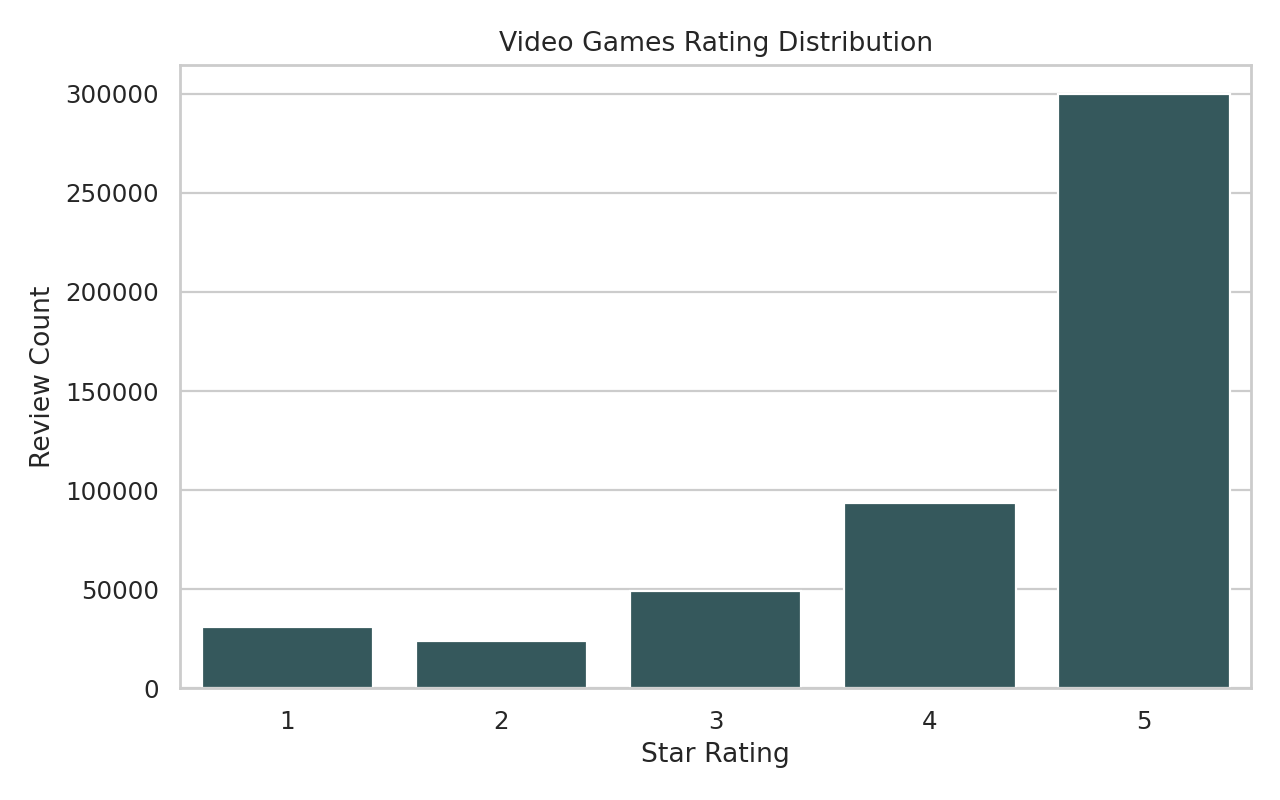

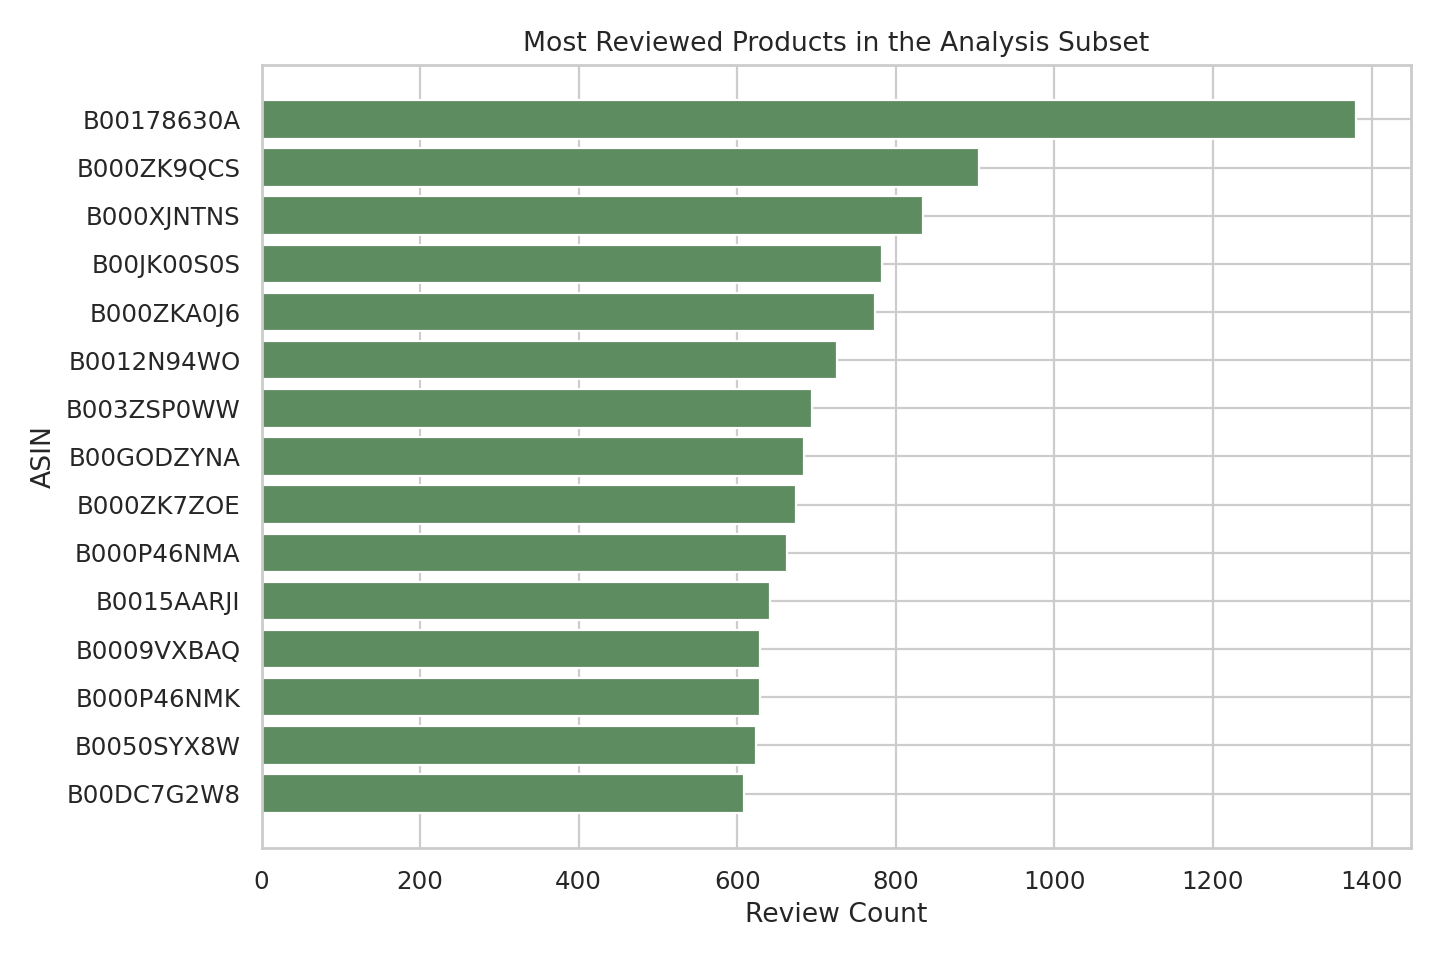

,subset_products,avg_reviews_per_product,median_reviews_per_product,avg_rating_in_subset
0,400,293.3,252.5,4.312


In [4]:
subset_overview = pd.DataFrame(
    [
        {
            "subset_products": len(product_documents),
            "avg_reviews_per_product": round(product_documents["review_count"].mean(), 1),
            "median_reviews_per_product": round(product_documents["review_count"].median(), 1),
            "avg_rating_in_subset": round(product_documents["mean_rating"].mean(), 3),
        }
    ]
)

display(Image(filename=str(OUTPUT_DIR / "figures/rating_distribution.png")))
display(Image(filename=str(OUTPUT_DIR / "figures/top_products.png")))
subset_overview


## Semantic View: What the Review Text Says

            The semantic pipeline clusters product-level review documents using TF-IDF. The best solution on this subset uses **3** clusters with a silhouette score of **0.167**. The resulting groups are interpretable rather than arbitrary:

            - Text cluster 0 is characterized by `game, like, just, great, games, play, fun, good, story, time`.
- Text cluster 1 is characterized by `great, controller, games, stars, wii, works, good, just, like, game`.
- Text cluster 2 is characterized by `mouse, razer, logitech, gaming mouse, mice, great mouse, dpi, buttons, naga, great`.

            The main pattern is that one large cluster captures general game-discussion language, while smaller clusters isolate hardware-heavy review vocabulary such as controllers, Wii accessories, and gaming mice. That tells us the text is sensitive to product type and usage context.


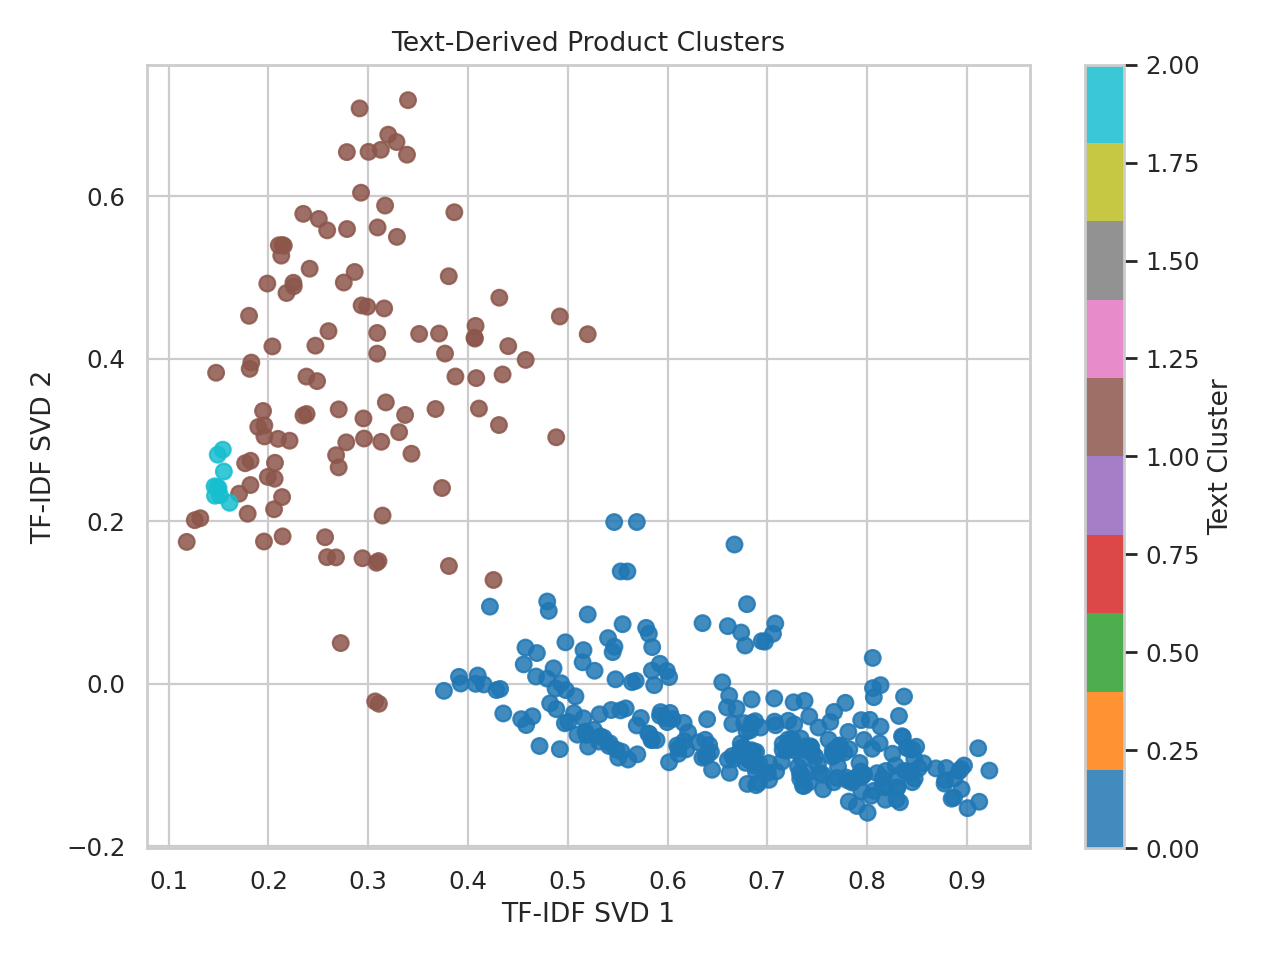

,cluster,top_terms
0,0,"game, like, just, great, games, play, fun, good, story, time"
1,1,"great, controller, games, stars, wii, works, good, just, like, game"
2,2,"mouse, razer, logitech, gaming mouse, mice, great mouse, dpi, buttons, naga, great"


,products,avg_reviews,avg_rating,avg_pagerank
text_cluster,,,,
0,283,295.491,4.275,0.003
1,108,285.963,4.412,0.002
2,9,311.667,4.262,0.002


In [5]:
semantic_profile = (
    product_documents.groupby("text_cluster")
    .agg(
        products=("asin", "size"),
        avg_reviews=("review_count", "mean"),
        avg_rating=("mean_rating", "mean"),
        avg_pagerank=("pagerank", "mean"),
    )
    .round(3)
    .sort_values("products", ascending=False)
)

display(Image(filename=str(OUTPUT_DIR / "figures/text_clusters.png")))
display(cluster_terms)
semantic_profile


## Structural View: Who Reviews the Same Products

The structural view throws away the words and keeps only reviewer overlap. Two products are connected when they share at least **2** reviewers. On this subset, that produces a surprisingly dense network with **33,613** weighted edges and **6** graph communities.

This matters because reviewer overlap is not the same as textual similarity. A reviewer can move across products for many reasons: franchise loyalty, hardware compatibility, gift shopping, or platform preference. The graph therefore captures audience pathways that are partly hidden from the text model.


,nodes,edges,density,graph communities,best graph clusters
0,400,33613,0.421,6,8


,asin,review_count,mean_rating,pagerank,weighted_degree,graph_community
3,B00JK00S0S,783,4.690932,0.008253,3818,1
7,B00GODZYNA,684,4.644737,0.007769,3584,1
16,B00KVR4HEC,573,4.270506,0.007031,3211,1
23,B00BGA9YZK,543,3.902394,0.006583,2997,1
20,B00BGA9Y3W,557,3.552962,0.006532,2967,1
9,B000P46NMA,663,4.126697,0.006320,2738,2
51,B000UW21A0,423,4.423168,0.006277,2730,2
14,B00DC7G2W8,608,4.740132,0.006209,2609,3
12,B000P46NMK,629,4.012719,0.006067,2561,0
45,B000FQ2D5E,432,4.520833,0.005969,2570,2


,community,size
0,0,135
1,1,78
2,2,69
3,3,66
4,4,30
5,5,22


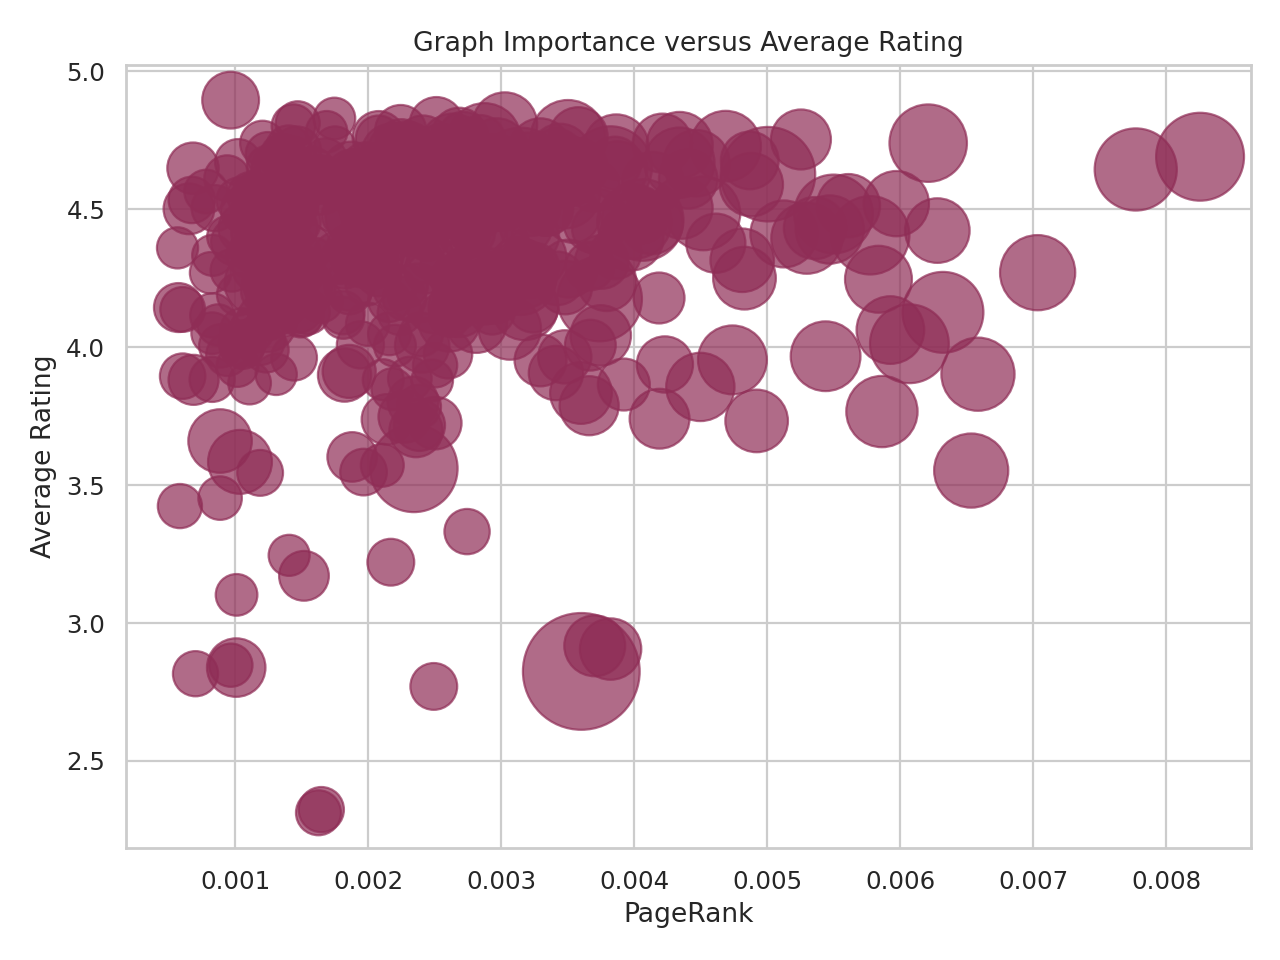

In [6]:
graph_overview = pd.DataFrame(
    [
        {
            "nodes": summary["graph_nodes"],
            "edges": summary["graph_edges"],
            "density": round(summary["graph_density"], 3),
            "graph communities": summary["community_count"],
            "best graph clusters": summary["best_graph_k"],
        }
    ]
)

top_pagerank = product_documents[
    ["asin", "review_count", "mean_rating", "pagerank", "weighted_degree", "graph_community"]
].sort_values("pagerank", ascending=False).head(15)

display(graph_overview)
display(top_pagerank)
display(community_sizes.head(10))
display(Image(filename=str(OUTPUT_DIR / "figures/pagerank_vs_rating.png")))


## Direct Comparison: Do the Two Views Agree?

This is the core question of the project. If the semantic and structural views told the same story, products grouped together by review language would also be grouped together by reviewer overlap. That is not what happens here.

The alignment score between the text clusters and graph clusters is only **0.068**. That is far closer to weak agreement than to a one-to-one match. In other words, products that *sound* similar in reviews do not reliably occupy the same position in the shared-reviewer network.

This is the central conclusion of the notebook: semantic similarity is useful, but it cannot substitute for structural information about who reviews what.


In [7]:
alignment_table = pd.crosstab(
    product_documents["text_cluster"],
    product_documents["graph_cluster"],
    rownames=["text cluster"],
    colnames=["graph cluster"],
)

alignment_share = alignment_table.div(alignment_table.sum(axis=1), axis=0).round(3)
dominant_graph_share = alignment_share.max(axis=1).rename("largest graph-cluster share")

display(alignment_table)
pd.concat([alignment_share, dominant_graph_share], axis=1)


graph cluster,0,1,2,3,4,5,6,7
text cluster,,,,,,,,
0,22,28,26,55,54,61,22,15
1,10,8,21,14,7,17,15,16
2,0,0,0,0,0,0,0,9


,0,1,2,3,4,5,6,7,largest graph-cluster share
text cluster,,,,,,,,,
0,0.078,0.099,0.092,0.194,0.191,0.216,0.078,0.053,0.216
1,0.093,0.074,0.194,0.130,0.065,0.157,0.139,0.148,0.194
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000


## Interpretation Extension: Topic Modeling

            Topic modeling is not the final answer, but it helps explain why the semantic clusters look the way they do. The LDA model recovers recurring themes that line up with recognizable subdomains of the category, including gameplay language, Nintendo/Wii-oriented discussion, shooter-specific vocabulary, and hardware/controller talk.

            - Topic 0 is summarized by `game, like, play, just, time, games, really, don, fun, good`.
- Topic 1 is summarized by `game, like, just, story, games, great, good, time, really, fun`.
- Topic 2 is summarized by `game, like, games, just, story, great, good, play, really, time`.
- Topic 3 is summarized by `game, wii, games, mario, fun, nintendo, play, great, like, new`.
- Topic 4 is summarized by `game, like, halo, play, just, great, multiplayer, fun, good, games`.
- Topic 5 is summarized by `great, controller, games, good, stars, works, just, like, mouse, xbox`.

            This extension is useful because it turns the text clusters from a geometric result into a substantive interpretation.


In [8]:
topic_by_cluster = pd.crosstab(
    product_documents["text_cluster"],
    product_documents["dominant_topic"],
    normalize="index",
).round(3)

display(topic_terms)
topic_by_cluster


,topic,top_terms
0,0,"game, like, play, just, time, games, really, don, fun, good"
1,1,"game, like, just, story, games, great, good, time, really, fun"
2,2,"game, like, games, just, story, great, good, play, really, time"
3,3,"game, wii, games, mario, fun, nintendo, play, great, like, new"
4,4,"game, like, halo, play, just, great, multiplayer, fun, good, games"
5,5,"great, controller, games, good, stars, works, just, like, mouse, xbox"


dominant_topic,0,1,2,3,4,5
text_cluster,,,,,,
0,0.117,0.318,0.233,0.131,0.201,0.000
1,0.019,0.009,0.009,0.167,0.000,0.796
2,0.000,0.000,0.000,0.000,0.000,1.000


## Limitations and Ethical Notes

This analysis is informative, but it is not neutral or complete.

- The Amazon 5-core dataset keeps only products and users with at least five interactions, so it already filters the market before analysis begins.
- The notebook works at the product level without metadata such as product title or platform, which limits human interpretability of ASIN-level tables.
- Amazon reviews are voluntary and often polarized, so the text reflects who chooses to post rather than all customers.
- Reviewer overlap may reflect popularity, compatibility, or franchise spillover rather than genuine product similarity.

These caveats do not invalidate the result, but they do explain why semantic and structural signals should be interpreted as complementary rather than definitive.


## Conclusion

The final answer to the project question is clear: **products that look similar in review language do not consistently occupy the same place in the shared-reviewer graph**. The low alignment score of **0.068** shows that the two views disagree more often than they coincide.

The text model mainly separates broad product types and recurring discussion themes. The graph model instead captures audience overlap and product pathways. Those are different mechanisms, and that difference is exactly why combining semantic and structural mining is more informative than using either one alone.

A second practical takeaway is that graph importance is only weakly connected to perceived product quality in this subset: the rating-to-PageRank correlation is just **0.089**. Popularly connected products are not simply the highest-rated ones.
